<a href="https://colab.research.google.com/github/paolalarap/challenge_TelecomX2_palp/blob/main/Challenge_TelecomX2_palp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafío Telecom X Parte 2:


*  Objetivo Principal: Anticipar la evasión de clientes identificando quiénes están en riesgo, qué variables influyen y qué perfiles requieren mayor atención.
*   Preparación de Datos: Utilizarás los datos tratados en el Challenge anterior, realizando preparaciones adicionales para modelos predictivos, como eliminar columnas irrelevantes y normalizar datos.
  https://github.com/paolalarap/challenge_TelecomX_palp.git



In [18]:
import pandas as pd

## **Preparación de los datos**

a) Extracción de archivo del desafío anterior

In [19]:
url='https://raw.githubusercontent.com/paolalarap/challenge_TelecomX2_palp/refs/heads/main/datos_clientes.csv'

In [20]:
datos_clientes=pd.read_csv(url)

In [21]:
datos_clientes.head()

,id_cliente,cancelacion,cliente.genero,cliente.ciudadano_senior,cliente.pareja,cliente.dependientes,cliente.antiguedad,telefono.servicio_telefonico,telefono.lineas_multiples,internet.servicio_internet,...,internet.proteccion_dispositivo,internet.soporte_tecnico,internet.tv_streaming,internet.peliculas_streaming,cuenta.contrato,cuenta.facturacion_sin_papel,cuenta.metodo_pago,cuenta.cargos_mensuales,cuenta.cargos_totales,cuenta_diaria
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


b) Eliminación de Columnas Irrelevantes

In [22]:
datos_clientes = datos_clientes[datos_clientes["cancelacion"].notna()]
datos_clientes= datos_clientes[datos_clientes["cancelacion"].str.strip() != ""]


In [23]:
datos_clientes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_cliente                       7043 non-null   object 
 1   cancelacion                      7043 non-null   object 
 2   cliente.genero                   7043 non-null   object 
 3   cliente.ciudadano_senior         7043 non-null   int64  
 4   cliente.pareja                   7043 non-null   object 
 5   cliente.dependientes             7043 non-null   object 
 6   cliente.antiguedad               7043 non-null   int64  
 7   telefono.servicio_telefonico     7043 non-null   object 
 8   telefono.lineas_multiples        7043 non-null   object 
 9   internet.servicio_internet       7043 non-null   object 
 10  internet.seguridad_en_linea      7043 non-null   object 
 11  internet.copia_seguridad         7043 non-null   object 
 12  internet.proteccion_dispo

In [24]:
# Eliminación de columnas
columnas_eliminar = [
    'id_cliente',
    'cliente.genero',
    'telefono.servicio_telefonico',
    'telefono.lineas_multiples',
    'internet.copia_seguridad',
    'internet.proteccion_dispositivo',
    'internet.peliculas_streaming',
    'cuenta.facturacion_sin_papel'
]

datos_clientes= datos_clientes.drop(columns=columnas_eliminar, errors='ignore')



In [25]:
datos_clientes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cancelacion                  7043 non-null   object 
 1   cliente.ciudadano_senior     7043 non-null   int64  
 2   cliente.pareja               7043 non-null   object 
 3   cliente.dependientes         7043 non-null   object 
 4   cliente.antiguedad           7043 non-null   int64  
 5   internet.servicio_internet   7043 non-null   object 
 6   internet.seguridad_en_linea  7043 non-null   object 
 7   internet.soporte_tecnico     7043 non-null   object 
 8   internet.tv_streaming        7043 non-null   object 
 9   cuenta.contrato              7043 non-null   object 
 10  cuenta.metodo_pago           7043 non-null   object 
 11  cuenta.cargos_mensuales      7043 non-null   float64
 12  cuenta.cargos_totales        7032 non-null   float64
 13  cuenta_diaria          

In [26]:
datos_clientes.head()

,cancelacion,cliente.ciudadano_senior,cliente.pareja,cliente.dependientes,cliente.antiguedad,internet.servicio_internet,internet.seguridad_en_linea,internet.soporte_tecnico,internet.tv_streaming,cuenta.contrato,cuenta.metodo_pago,cuenta.cargos_mensuales,cuenta.cargos_totales,cuenta_diaria
0,No,0,Yes,Yes,9,DSL,No,Yes,Yes,One year,Mailed check,65.6,593.30,2.186667
1,No,0,No,No,9,DSL,No,No,No,Month-to-month,Mailed check,59.9,542.40,1.996667
2,Yes,0,No,No,4,Fiber optic,No,No,No,Month-to-month,Electronic check,73.9,280.85,2.463333
3,Yes,1,Yes,No,13,Fiber optic,No,No,Yes,Month-to-month,Electronic check,98.0,1237.85,3.266667
4,Yes,1,Yes,No,3,Fiber optic,No,Yes,Yes,Month-to-month,Mailed check,83.9,267.40,2.796667


c) Encoding

In [27]:
# Seleccionar columnas categóricas automáticamente
columnas_categoricas = datos_clientes.select_dtypes(include=['object']).columns

# Aplicar One-Hot Encoding con get_dummies
datos_clientes_codificado = pd.get_dummies(
    datos_clientes,
    columns=columnas_categoricas,
    drop_first=True
)


In [28]:
datos_clientes_codificado.head()

,cliente.ciudadano_senior,cliente.antiguedad,cuenta.cargos_mensuales,cuenta.cargos_totales,cuenta_diaria,cancelacion_Yes,cliente.pareja_Yes,cliente.dependientes_Yes,internet.servicio_internet_Fiber optic,internet.servicio_internet_No,...,internet.seguridad_en_linea_Yes,internet.soporte_tecnico_No internet service,internet.soporte_tecnico_Yes,internet.tv_streaming_No internet service,internet.tv_streaming_Yes,cuenta.contrato_One year,cuenta.contrato_Two year,cuenta.metodo_pago_Credit card (automatic),cuenta.metodo_pago_Electronic check,cuenta.metodo_pago_Mailed check
0,0,9,65.6,593.30,2.186667,False,True,True,False,False,...,False,False,True,False,True,True,False,False,False,True
1,0,9,59.9,542.40,1.996667,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,0,4,73.9,280.85,2.463333,True,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
3,1,13,98.0,1237.85,3.266667,True,True,False,True,False,...,False,False,False,False,True,False,False,False,True,False
4,1,3,83.9,267.40,2.796667,True,True,False,True,False,...,False,False,True,False,True,False,False,False,False,True


In [29]:
datos_clientes_codificado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   cliente.ciudadano_senior                         7043 non-null   int64  
 1   cliente.antiguedad                               7043 non-null   int64  
 2   cuenta.cargos_mensuales                          7043 non-null   float64
 3   cuenta.cargos_totales                            7032 non-null   float64
 4   cuenta_diaria                                    7043 non-null   float64
 5   cancelacion_Yes                                  7043 non-null   bool   
 6   cliente.pareja_Yes                               7043 non-null   bool   
 7   cliente.dependientes_Yes                         7043 non-null   bool   
 8   internet.servicio_internet_Fiber optic           7043 non-null   bool   
 9   internet.servicio_internet_No      

d) Verificación de la Proporción de Cancelación (Churn)

*Dato: El desbalance se realiza con la data original, o sea, antes de codificar. Porque:*
* *Necesitas ver la distribución real de la variable objetivo*
* *Necesitas saber si hay un problema de desbalance ANTES de preparar los datos*
* *Técnicas como SMOTE, undersampling o class weights se aplican después, pero   requieren conocer el desbalance original*


In [30]:
# Conteo de clases
conteo = datos_clientes['cancelacion'].value_counts()

# Proporción de clases
proporcion = datos_clientes['cancelacion'].value_counts(normalize=True) * 100

print("Conteo de clases:")
print(conteo)

print("\nProporción de clases (%):")
print(proporcion)

# Evaluación automática del desbalance
print("\nEvaluación del balance de clases:")

if proporcion.max() > 70:
    print("⚠️ Existe un desbalance significativo entre las clases. Será necesario aplicar técnicas de balanceo antes del modelado.")
elif proporcion.max() > 60:
    print("⚠️ Hay un desbalance moderado. Se recomienda evaluar técnicas de balanceo.")
else:
    print("✔️ Las clases están relativamente balanceadas. No se requiere balanceo obligatorio.")

Conteo de clases:
cancelacion
No     5174
Yes    1869
Name: count, dtype: int64

Proporción de clases (%):
cancelacion
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Evaluación del balance de clases:
⚠️ Existe un desbalance significativo entre las clases. Será necesario aplicar técnicas de balanceo antes del modelado.


e) Normalización de datos

In [31]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split


In [32]:
datos_clientes_codificado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   cliente.ciudadano_senior                         7043 non-null   int64  
 1   cliente.antiguedad                               7043 non-null   int64  
 2   cuenta.cargos_mensuales                          7043 non-null   float64
 3   cuenta.cargos_totales                            7032 non-null   float64
 4   cuenta_diaria                                    7043 non-null   float64
 5   cancelacion_Yes                                  7043 non-null   bool   
 6   cliente.pareja_Yes                               7043 non-null   bool   
 7   cliente.dependientes_Yes                         7043 non-null   bool   
 8   internet.servicio_internet_Fiber optic           7043 non-null   bool   
 9   internet.servicio_internet_No      

In [33]:
columnas_numericas = datos_clientes_codificado.select_dtypes(include=['int64', 'float64']).columns

# Creamos copia para no modificar el original
datos_cliente_normalizado = datos_clientes_codificado.copy()

# Aplicando normalización MinMax
scaler = MinMaxScaler()
datos_cliente_normalizado[columnas_numericas] = scaler.fit_transform(datos_cliente_normalizado[columnas_numericas])


In [34]:
datos_cliente_normalizado.head()

,cliente.ciudadano_senior,cliente.antiguedad,cuenta.cargos_mensuales,cuenta.cargos_totales,cuenta_diaria,cancelacion_Yes,cliente.pareja_Yes,cliente.dependientes_Yes,internet.servicio_internet_Fiber optic,internet.servicio_internet_No,...,internet.seguridad_en_linea_Yes,internet.soporte_tecnico_No internet service,internet.soporte_tecnico_Yes,internet.tv_streaming_No internet service,internet.tv_streaming_Yes,cuenta.contrato_One year,cuenta.contrato_Two year,cuenta.metodo_pago_Credit card (automatic),cuenta.metodo_pago_Electronic check,cuenta.metodo_pago_Mailed check
0,0.0,0.125000,0.471144,0.066294,0.471144,False,True,True,False,False,...,False,False,True,False,True,True,False,False,False,True
1,0.0,0.125000,0.414428,0.060420,0.414428,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,0.0,0.055556,0.553731,0.030239,0.553731,True,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
3,1.0,0.180556,0.793532,0.140670,0.793532,True,True,False,True,False,...,False,False,False,False,True,False,False,False,True,False
4,1.0,0.041667,0.653234,0.028687,0.653234,True,True,False,True,False,...,False,False,True,False,True,False,False,False,False,True


## Correlación y Selección de Variables

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt



a) Análisis de Correlacción

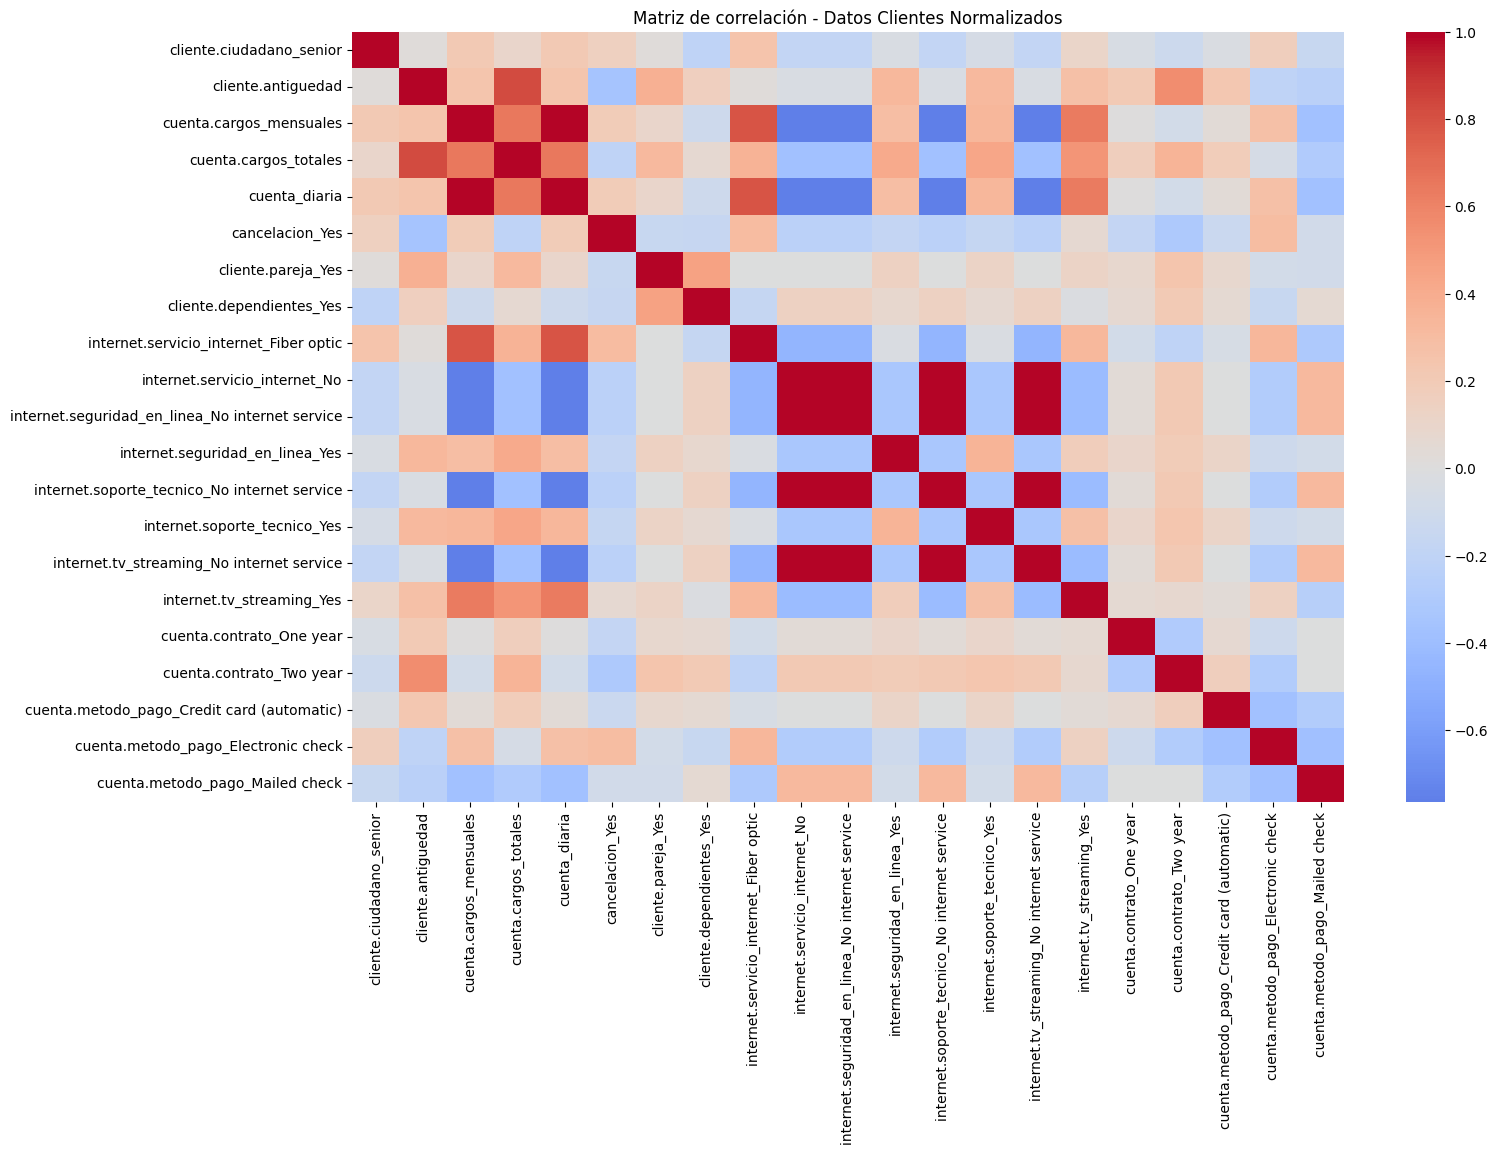

In [36]:
# Matriz de correlación
corr = datos_cliente_normalizado.corr()

plt.figure(figsize=(16, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Matriz de correlación - Datos Clientes Normalizados")
plt.show()


In [37]:
# Correlación con la variable objetivo
# Dato: Esto es lo más importante para tu análisis, responde a la pregunta
# ¿Qué variables están más relacionadas con la cancelación?
# y la respuesta es una lista ordenada desde la correlación más alta a la más baja

correlacion_target = corr['cancelacion_Yes'].sort_values(ascending=False)

correlacion_target


,cancelacion_Yes
cancelacion_Yes,1.000000
internet.servicio_internet_Fiber optic,0.308020
cuenta.metodo_pago_Electronic check,0.301919
cuenta_diaria,0.193356
cuenta.cargos_mensuales,0.193356
cliente.ciudadano_senior,0.150889
internet.tv_streaming_Yes,0.063228
cuenta.metodo_pago_Mailed check,-0.091683
cuenta.metodo_pago_Credit card (automatic),-0.134302
cliente.pareja_Yes,-0.150448


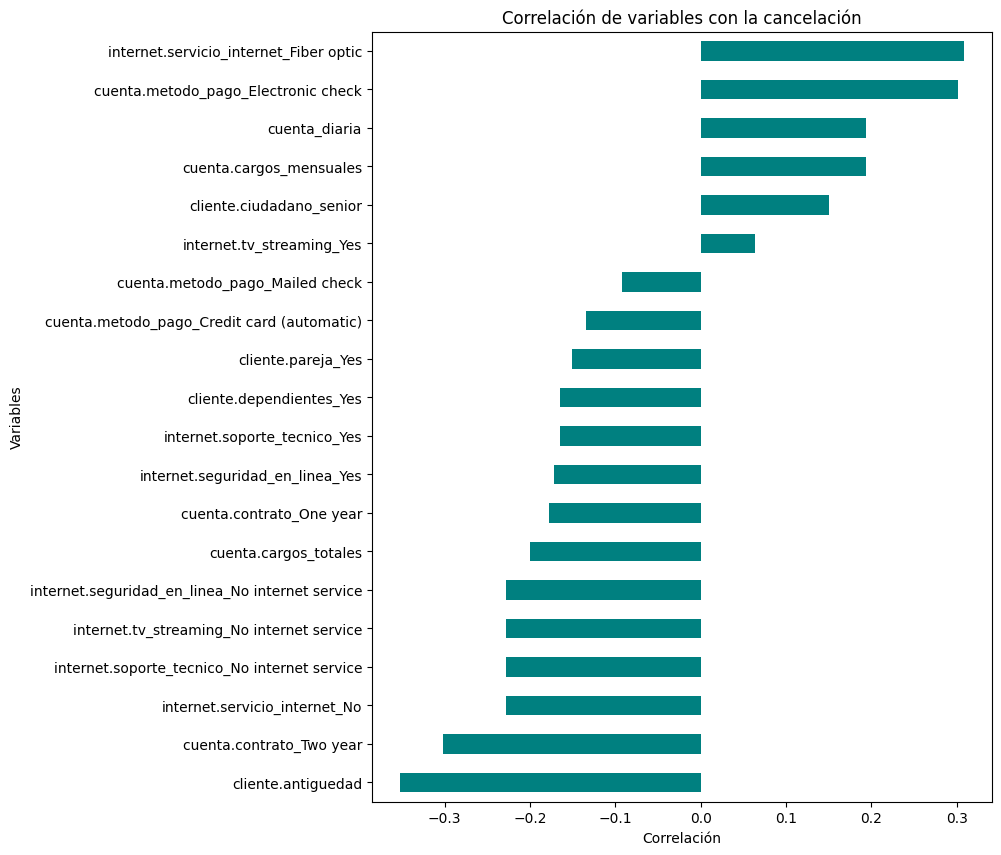

In [38]:
plt.figure(figsize=(8, 10))
correlacion_target.drop('cancelacion_Yes').sort_values().plot(kind='barh', color='teal')
plt.title("Correlación de variables con la cancelación")
plt.xlabel("Correlación")
plt.ylabel("Variables")
plt.show()

In [39]:

correlaciones = {
    "cancelacion_Yes": 1.000000,
    "internet.servicio_internet_Fiber optic": 0.308020,
    "cuenta.metodo_pago_Electronic check": 0.301919,
    "cuenta_diaria": 0.193356,
    "cuenta.cargos_mensuales": 0.193356,
    "cliente.ciudadano_senior": 0.150889,
    "internet.tv_streaming_Yes": 0.063228,
    "cuenta.metodo_pago_Mailed check": -0.091683,
    "cuenta.metodo_pago_Credit card (automatic)": -0.134302,
    "cliente.pareja_Yes": -0.150448,
    "cliente.dependientes_Yes": -0.164221,
    "internet.soporte_tecnico_Yes": -0.164674,
    "internet.seguridad_en_linea_Yes": -0.171226,
    "cuenta.contrato_One year": -0.177820,
    "cuenta.cargos_totales": -0.199484,
    "internet.soporte_tecnico_No internet service": -0.227890,
    "internet.servicio_internet_No": -0.227890,
    "internet.tv_streaming_No internet service": -0.227890,
    "internet.seguridad_en_linea_No internet service": -0.227890,
    "cuenta.contrato_Two year": -0.302253,
    "cliente.antiguedad": -0.352229
}


def interpretar_correlacion(variable, valor):
    intensidad = ""
    if abs(valor) >= 0.30:
        intensidad = "fuerte"
    elif abs(valor) >= 0.15:
        intensidad = "moderada"
    else:
        intensidad = "débil"

    direccion = "positiva" if valor > 0 else "negativa"

    return f"- {variable}: correlación {intensidad} y {direccion} ({valor:.3f})."

print("INTERPRETACIÓN DE LAS CORRELACIONES CON LA CANCELACIÓN:\n")
for var, val in correlaciones.items():
    if var != "cancelacion_Yes":
        print(interpretar_correlacion(var, val))

INTERPRETACIÓN DE LAS CORRELACIONES CON LA CANCELACIÓN:

- internet.servicio_internet_Fiber optic: correlación fuerte y positiva (0.308).
- cuenta.metodo_pago_Electronic check: correlación fuerte y positiva (0.302).
- cuenta_diaria: correlación moderada y positiva (0.193).
- cuenta.cargos_mensuales: correlación moderada y positiva (0.193).
- cliente.ciudadano_senior: correlación moderada y positiva (0.151).
- internet.tv_streaming_Yes: correlación débil y positiva (0.063).
- cuenta.metodo_pago_Mailed check: correlación débil y negativa (-0.092).
- cuenta.metodo_pago_Credit card (automatic): correlación débil y negativa (-0.134).
- cliente.pareja_Yes: correlación moderada y negativa (-0.150).
- cliente.dependientes_Yes: correlación moderada y negativa (-0.164).
- internet.soporte_tecnico_Yes: correlación moderada y negativa (-0.165).
- internet.seguridad_en_linea_Yes: correlación moderada y negativa (-0.171).
- cuenta.contrato_One year: correlación moderada y negativa (-0.178).
- cuenta

In [46]:

def generar_conclusion(correlaciones):
    conclusion = "CONCLUSIÓN SOBRE LAS CORRELACIONES CON LA CANCELACIÓN:\n\n"

    # Variables con correlación positiva (aumentan probabilidad de cancelación)
    positivas = {k:v for k,v in correlaciones.items() if v > 0.15}
    # Variables con correlación negativa (disminuyen probabilidad de cancelación)
    negativas = {k:v for k,v in correlaciones.items() if v < -0.15}

    conclusion += "🔺 Variables que AUMENTAN la probabilidad de cancelación:\n"
    if positivas:
        for var, val in sorted(positivas.items(), key=lambda x: -x[1]):
            conclusion += f"  • {var} (correlación {val:.3f})\n"
    else:
        conclusion += "  • No se identificaron variables relevantes.\n"

    conclusion += "\n🔻 Variables que DISMINUYEN la probabilidad de cancelación:\n"
    if negativas:
        for var, val in sorted(negativas.items(), key=lambda x: x[1]):
            conclusion += f"  • {var} (correlación {val:.3f})\n"
    else:
        conclusion += "  • No se identificaron variables relevantes.\n"

    # Conclusión general
    conclusion += "\n📌 Conclusión general:\n"
    conclusion += (
        "Las correlaciones muestran que ciertos factores del servicio y del método de pago "
        "están asociados a una mayor probabilidad de cancelación, especialmente el uso de "
        "servicio de fibra óptica y el método de pago Electronic Check. Por otro lado, la "
        "antigüedad del cliente y los contratos de mayor duración se asocian fuertemente con "
        "una menor probabilidad de cancelación, lo que indica que la permanencia y los planes "
        "de largo plazo son factores protectores contra el churn.\n"
    )

    return conclusion


print(generar_conclusion(correlaciones))

CONCLUSIÓN SOBRE LAS CORRELACIONES CON LA CANCELACIÓN:

🔺 Variables que AUMENTAN la probabilidad de cancelación:
  • internet.servicio_internet_Fiber optic (correlación 0.308)
  • cuenta.metodo_pago_Electronic check (correlación 0.302)
  • cuenta_diaria (correlación 0.193)
  • cuenta.cargos_mensuales (correlación 0.193)
  • cliente.ciudadano_senior (correlación 0.151)

🔻 Variables que DISMINUYEN la probabilidad de cancelación:
  • cliente.antiguedad (correlación -0.352)
  • cuenta.contrato_Two year (correlación -0.302)
  • internet.soporte_tecnico_No internet service (correlación -0.228)
  • internet.servicio_internet_No (correlación -0.228)
  • internet.tv_streaming_No internet service (correlación -0.228)
  • internet.seguridad_en_linea_No internet service (correlación -0.228)
  • cuenta.cargos_totales (correlación -0.199)
  • cuenta.contrato_One year (correlación -0.178)
  • internet.seguridad_en_linea_Yes (correlación -0.171)
  • internet.soporte_tecnico_Yes (correlación -0.165)
  